# Train MobileNetV3-Small For Doodle classification

## Setup Environment

In [ ]:
!nvidia-smi
!pip install torch torchvision tqdm

Mon Nov 17 15:11:25 2025       
+-----------------------------------------------------------------------------------------+
| NVIDIA-SMI 550.54.15              Driver Version: 550.54.15      CUDA Version: 12.4     |
|-----------------------------------------+------------------------+----------------------+
| GPU  Name                 Persistence-M | Bus-Id          Disp.A | Volatile Uncorr. ECC |
| Fan  Temp   Perf          Pwr:Usage/Cap |           Memory-Usage | GPU-Util  Compute M. |
|                                         |                        |               MIG M. |
|=========================================+========================+======================|
|   0  Tesla T4                       Off |   00000000:00:04.0 Off |                    0 |
| N/A   38C    P8              9W /   70W |       0MiB /  15360MiB |      0%      Default |
|                                         |                        |                  N/A |
+-----------------------------------------+-----

## Download QuickDraw Dataset (20 classes)

In [ ]:
import os
import urllib.request
import urllib.parse
from tqdm import tqdm

# --- Configuration ---

CLASSES = [
    "cat", "dog", "bird", "fish",
    "apple", "banana", "pizza", "cake", "ice cream",
    "car", "house", "tree", "flower", "sun", "cloud",
    "star", "moon", "hand", "face", "clock"
]

BASE_URL = "https://storage.googleapis.com/quickdraw_dataset/full/numpy_bitmap/"
DATA_DIR = "quickdraw_data"

# Ensure the data directory exists
os.makedirs(DATA_DIR, exist_ok=True)

# --- Functions ---

class TqdmUpTo(tqdm):
    """
    Provides hook for urllib.request.urlretrieve to report progress to a tqdm bar.
    """
    def update_to(self, b=1, bsize=1, tsize=None):
        if tsize is not None:
            self.total = tsize
        self.update(b * bsize - self.n)

def download_class(cname):
    """Downloads a single QuickDraw class numpy file."""

    # URL Encode the class name (handles spaces like "ice cream" -> "ice%20cream")
    encoded_cname = urllib.parse.quote(cname)

    url = f"{BASE_URL}{encoded_cname}.npy"
    dest = os.path.join(DATA_DIR, f"{cname}.npy")

    if os.path.exists(dest):
        return

    # Use a try-except block to catch potential HTTP Errors
    try:
        # Use TqdmUpTo class for a visible progress bar per file
        with TqdmUpTo(unit='B', unit_scale=True, miniters=1,
                      desc=f"Downloading {cname}") as t:
            urllib.request.urlretrieve(url, dest, reporthook=t.update_to)

    except urllib.error.HTTPError as e:
        print(f"\n ERROR downloading {cname}: HTTP Error {e.code} ({e.reason})")
        print(f"URL: {url}")
    except Exception as e:
        print(f"\n ERROR downloading {cname}: {e}")

# --- Main Execution ---

print("Starting QuickDraw dataset download...")
# Run the main loop
for c in CLASSES:
    download_class(c)

print("\n All downloads complete (or existing files skipped)!")

Starting QuickDraw dataset download...



 All downloads complete (or existing files skipped)!


## Create Dataset Loader

In [ ]:
import numpy as np
import torch
from torch.utils.data import Dataset
import cv2

class QuickDrawDataset(Dataset):
    def __init__(self, data_dir, class_list, max_samples=None):
        self.data = []
        self.labels = []
        self.class_list = class_list

        print("Loading dataset...")

        for idx, cname in enumerate(class_list):
            arr = np.load(f"{data_dir}/{cname}.npy")

            if max_samples:
                arr = arr[:max_samples]

            self.data.append(arr)
            self.labels += [idx] * len(arr)

        self.data = np.vstack(self.data).astype(np.uint8)
        self.labels = np.array(self.labels)

        # Shuffle
        p = np.random.permutation(len(self.data))
        self.data = self.data[p]
        self.labels = self.labels[p]

        print(f"Loaded {len(self.data)} total images.")

    def __len__(self):
        return len(self.data)

    def __getitem__(self, idx):
        img = self.data[idx].reshape(28, 28)

        # Resize to 64x64 using INTER_LINEAR (faster than INTER_AREA)
        img = cv2.resize(img, (64, 64), interpolation=cv2.INTER_LINEAR)

        # Normalize
        img = img.astype(np.float32) / 255.0

        # Add channel dim
        img = torch.tensor(img).unsqueeze(0)

        label = int(self.labels[idx])
        return img, label

## CNN Model Architecture
- This is a MobileNetV2-inspired small CNN.
- Fast on CPU + high accuracy.

In [ ]:
import torch
import torch.nn as nn
from torchvision.models import mobilenet_v3_small

class MobileNetV3Doodle(nn.Module):
    def __init__(self, num_classes=30):
        super().__init__()

        self.model = mobilenet_v3_small(weights=None)

        # Modify first layer to accept 1 channel (grayscale)
        self.model.features[0][0] = nn.Conv2d(
            1, 16, kernel_size=3, stride=2, padding=1, bias=False
        )

        # Replace classifier
        self.model.classifier[3] = nn.Linear(1024, num_classes)

    def forward(self, x):
        return self.model(x)

# Training

In [ ]:
from torch.utils.data import DataLoader, random_split
import torch.optim as optim
from tqdm import tqdm
import torch.nn as nn
import torch
from torch.amp import autocast, GradScaler

def train_model():
    device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
    print("Device:", device)

    # AMP Setup
    scaler = GradScaler()
    print("Enabled Automatic Mixed Precision (AMP).")

    # Dataset
    dataset = QuickDrawDataset(DATA_DIR, CLASSES)

    train_size = int(0.90 * len(dataset))
    val_size = len(dataset) - train_size
    train_ds, val_ds = random_split(dataset, [train_size, val_size])

    # Large batch settings
    BATCH_SIZE = 4062
    NUM_WORKERS = 2  # safe for Colab / CPU/GPU

    print(f"Using Batch Size: {BATCH_SIZE}")
    print(f"Using {NUM_WORKERS} workers")

    # DataLoaders
    train_loader = DataLoader(
        train_ds,
        batch_size=BATCH_SIZE,
        shuffle=True,
        num_workers=NUM_WORKERS,
        pin_memory=True
    )

    val_loader = DataLoader(
        val_ds,
        batch_size=BATCH_SIZE,
        shuffle=False,
        num_workers=NUM_WORKERS,
        pin_memory=True
    )

    # Model
    model = MobileNetV3Doodle(num_classes=len(CLASSES)).to(device)

    # Loss
    criterion = nn.CrossEntropyLoss(label_smoothing=0.1)

    # Fixed learning rate for batch 4062
    LR = 0.022
    optimizer = optim.AdamW(model.parameters(), lr=LR, weight_decay=0.01)

    # Scheduler
    EPOCHS = 20


    best_val = 0

    # Training Loop
    for epoch in range(EPOCHS):
        model.train()
        correct = total = 0
        pbar = tqdm(train_loader, desc=f"Epoch {epoch+1}/{EPOCHS}")

        for imgs, labels in pbar:
            imgs, labels = imgs.to(device, non_blocking=True), labels.to(device, non_blocking=True)

            optimizer.zero_grad(set_to_none=True)

            with autocast(device_type='cuda'):
                out = model(imgs)
                loss = criterion(out, labels)

            scaler.scale(loss).backward()

            # Gradient clipping
            scaler.unscale_(optimizer)
            torch.nn.utils.clip_grad_norm_(model.parameters(), max_norm=1.0)

            scaler.step(optimizer)
            scaler.update()

            _, pred = out.max(1)
            total += labels.size(0)
            correct += pred.eq(labels).sum().item()

            pbar.set_postfix({
                "acc": f"{100*correct/total:.2f}%",
                "LR": f"{optimizer.param_groups[0]['lr']:.5f}"
            })

        # Validation
        model.eval()
        val_correct = val_total = 0
        with torch.no_grad():
            for imgs, labels in val_loader:
                imgs, labels = imgs.to(device, non_blocking=True), labels.to(device, non_blocking=True)
                with autocast(device_type='cuda'):
                    out = model(imgs)
                _, pred = out.max(1)
                val_total += labels.size(0)
                val_correct += pred.eq(labels).sum().item()

        val_acc = 100 * val_correct / val_total
        print(f"\nValidation Acc: {val_acc:.2f}%")

        if val_acc > best_val:
            best_val = val_acc
            torch.save(model.state_dict(), "doodlenet_best.pth")
            print(f"✓ Saved best model ({best_val:.2f}%)")

    print("\nTraining complete! Best Acc:", best_val)


if __name__ == "__main__":
    train_model()


Device: cuda
Enabled Automatic Mixed Precision (AMP).
Loading dataset...


## Test Inference

In [ ]:
import time

model = MobileNetV3Doodle(len(CLASSES))
model.load_state_dict(torch.load("doodlenet_best.pth", map_location="cpu"))
model.eval()

dummy = torch.randn(1,1,28,28)

# Warmup
for _ in range(10):
    model(dummy)

# Measure
start = time.time()
for _ in range(50):
    model(dummy)
end = time.time()

print("Avg inference:", (end-start)/50 * 1000, "ms")


Avg inference: 1.2542533874511719 ms


*** END ***

## Show top 5 conf classes

Model loaded.
Loaded: /content/quickdraw_data/apple.npy, shape: (144722, 784)


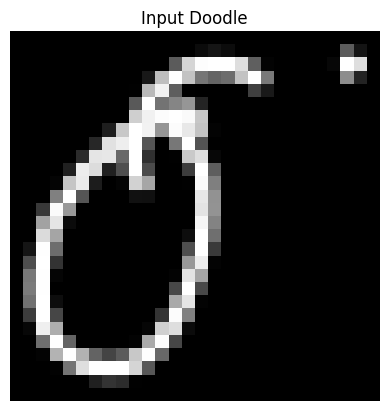


🎯 Prediction: **apple**  (67.73%)

Top-5 Predictions:
apple        → 67.73%
face         → 12.68%
bird         → 5.89%
circle       → 5.06%
clock        → 2.53%


In [ ]:
# -----------------------------
# CONFIG
# -----------------------------
DATA_DIR = "quickdraw_data" # directory where .npy files exist
FILE = "apple.npy" # <-- change this to the file you want
INDEX = 20 # which sample inside the .npy to test
MODEL_PATH = "doodlenet_best.pth" # your trained model

# -----------------------------
# LOAD MODEL
# -----------------------------
# Instantiate the model (replace MobileNetV3Doodle if your class name is different)
model = MobileNetV3Doodle(num_classes=len(CLASSES))
model.load_state_dict(torch.load(MODEL_PATH, map_location="cpu"))
model.eval()

print("Model loaded.")

# -----------------------------
# LOAD A DOODLE FROM .NPY FILE
# -----------------------------
npy_path = os.path.join(DATA_DIR, FILE)

try:
    arr = np.load(npy_path)
except FileNotFoundError:
    print(f"Error: File not found at {npy_path}. Make sure you ran the download script.")
    raise

print(f"Loaded: {npy_path}, shape: {arr.shape}")

# Pick a sample from the file and reshape to 28x28
img = arr[INDEX].reshape(28, 28).astype("float32")

# Normalize to match training (0–1)
img = img / 255.0

# -----------------------------
# PREPARE TENSOR
# -----------------------------
# Add batch dimension (1) and channel dimension (1) -> (1, 1, 28, 28)
tensor = torch.tensor(img).unsqueeze(0).unsqueeze(0)

# -----------------------------
# RUN INFERENCE
# -----------------------------
with torch.no_grad():
  out = model(tensor)
  probs = F.softmax(out, dim=1)[0].numpy()

top_idx = int(np.argmax(probs))
top_class = CLASSES[top_idx]
top_prob = probs[top_idx] * 100

# -----------------------------
# DISPLAY RESULT
# -----------------------------
plt.figure(figsize=(3, 3))
plt.imshow(img, cmap="gray")
plt.title(f"Input Doodle (Index {INDEX})")
plt.axis("off")
plt.show()

print(f"\n Prediction: **{top_class}**  ({top_prob:.2f}%)\n")

# Show top-5 predictions for clarity
top5 = probs.argsort()[-5:][::-1]
print("Top-5 Predictions:")
for idx in top5:
  print(f"{CLASSES[idx]:<12} → {probs[idx]*100:.2f}%")

## Predict max config doodle

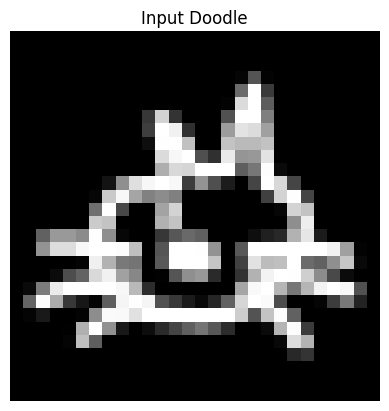


🎯 Predicted Class: **cat**
Confidence: 99.81%


In [ ]:
import numpy as np
import torch
import torch.nn.functional as F
import matplotlib.pyplot as plt

# -----------------------------
# CONFIG
# -----------------------------
DATA_DIR = "/content/quickdraw_data"    # directory where .npy files exist
FILE = "cat.npy"                        # change this to the file you want
INDEX = 0                               # sample index inside the file
MODEL_PATH = "doodlenet_best.pth"       # your trained model

# -----------------------------
# LOAD MODEL
# -----------------------------
model = DoodleNetPro(num_classes=len(CLASSES))
model.load_state_dict(torch.load(MODEL_PATH, map_location="cpu"))
model.eval()

# -----------------------------
# LOAD IMAGE
# -----------------------------
arr = np.load(f"{DATA_DIR}/{FILE}")
img = arr[INDEX].reshape(28, 28).astype("float32") / 255.0

tensor = torch.tensor(img).unsqueeze(0).unsqueeze(0)  # (1,1,28,28)

# -----------------------------
# INFERENCE
# -----------------------------
with torch.no_grad():
    out = model(tensor)
    probs = F.softmax(out, dim=1)[0].numpy()

# -----------------------------
# GET MAX-CONFIDENCE CLASS
# -----------------------------
max_idx = int(np.argmax(probs))
pred_class = CLASSES[max_idx]
pred_conf = probs[max_idx] * 100

# -----------------------------
# DISPLAY
# -----------------------------
plt.imshow(img, cmap="gray")
plt.title("Input Doodle")
plt.axis("off")
plt.show()

print(f"\n Predicted Class: **{pred_class}**")
print(f"Confidence: {pred_conf:.2f}%")
